# M3 – Segmentation client et M4 – Profilage des segments

**Responsable :** Miora

Ce notebook regroupe les modules M3 et M4 du projet.

- **M3** : construire des groupes de clients qui se ressemblent, à partir de leur âge, de leur comportement d'achat et de leurs préférences de produits.
- **M4** : décrire chaque groupe, lui donner un nom et en tirer un persona utilisable par la stratégie marketing (M7).

**Données utilisées :** `data/processed/clients_agreges.csv` et `data/processed/ventes_fusionnees.csv`
(les colonnes sont décrites dans `docs/regles_donnees.md`).

**Livrables :** `data/results/segments.csv`, les fiches personas ci-dessous et les graphiques `figures/m3_*.png` et `figures/m4_*.png`.

## 0. Préparation

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

RACINE = Path.cwd()
while not (RACINE / "data" / "processed").exists() and RACINE != RACINE.parent:
    RACINE = RACINE.parent
DATA = RACINE / "data" / "processed"
RESULTS = RACINE / "data" / "results"
FIGURES = RACINE / "figures"
RESULTS.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

GRAINE = 42
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (10, 5.5), "figure.dpi": 110, "font.size": 11,
                     "axes.titlesize": 13, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
BLEU, ORANGE = "#4C72B0", "#DD8452"
COULEURS_SEG = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

def sauver(fig, nom):
    fig.savefig(FIGURES / f"{nom}.png", dpi=150, bbox_inches="tight")

Matplotlib is building the font cache; this may take a moment.


In [2]:
clients = pd.read_csv(DATA / "clients_agreges.csv", parse_dates=["Join_Date", "Premier_Achat", "Dernier_Achat"])
ventes = pd.read_csv(DATA / "ventes_fusionnees.csv", parse_dates=["Date"])
print(f"{len(clients)} clients, dont {(clients['Nb_Achats'] == 0).sum()} sans aucun achat")

805 clients, dont 79 sans aucun achat


## 1. Préparation des variables

### 1.1 Clients retenus

Les clients qui n'ont jamais acheté n'ont ni panier moyen, ni récence, ni préférence de catégorie : ils ne peuvent pas être placés dans un groupe de comportement d'achat. Ils sont donc écartés de la segmentation et traités à part, comme un groupe « clients inactifs ». Ils restent dans le fichier de résultats avec le segment `-1`.

In [3]:
acheteurs = clients[clients["Nb_Achats"] > 0].copy()
inactifs = clients[clients["Nb_Achats"] == 0].copy()
print(f"Clients segmentés : {len(acheteurs)} — clients sans achat mis à part : {len(inactifs)}")

Clients segmentés : 726 — clients sans achat mis à part : 79


### 1.2 Choix des variables

Nous retenons trois familles de variables :

- **Profil** : l'âge. Le genre et la ville ont été écartés : l'exploration (M2) a montré qu'ils sont répartis de façon homogène et ne différencient pas les clients.
- **Comportement d'achat (RFM)** : la récence, le nombre d'achats (fréquence), le montant total dépensé et le panier moyen.
- **Préférences** : la part de chaque catégorie de produits dans les dépenses et la part des achats en ligne.

Le nombre d'achats et le montant total ont des distributions très asymétriques, comme l'a montré M2 : quelques clients dépensent beaucoup plus que les autres. Nous leur appliquons une transformation logarithmique pour éviter que ces valeurs extrêmes dominent le calcul des distances.

In [4]:
acheteurs["log_Nb_Achats"] = np.log1p(acheteurs["Nb_Achats"])
acheteurs["log_Montant_Total"] = np.log1p(acheteurs["Montant_Total"])

VARIABLES = ["Age", "log_Nb_Achats", "log_Montant_Total", "Panier_Moyen", "Recence_Jours",
             "Part_Online", "Part_Clothing", "Part_Footwear", "Part_Outerwear", "Part_Accessories"]

scaler = StandardScaler()
X = scaler.fit_transform(acheteurs[VARIABLES])
print(f"Matrice de segmentation : {X.shape[0]} clients, {X.shape[1]} variables normalisées")
acheteurs[VARIABLES].describe().round(1)

Matrice de segmentation : 726 clients, 10 variables normalisées


,Age,log_Nb_Achats,log_Montant_Total,Panier_Moyen,Recence_Jours,Part_Online,Part_Clothing,Part_Footwear,Part_Outerwear,Part_Accessories
count,726.0,726.0,726.0,726.0,726.0,726.0,726.0,726.0,726.0,726.0
mean,36.3,1.9,6.0,92.3,165.1,52.8,33.4,14.6,33.6,18.3
std,12.8,0.7,1.1,55.0,188.8,35.4,30.7,22.3,40.6,26.5
min,18.0,0.7,2.8,15.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,24.0,1.4,5.3,50.0,19.0,20.0,0.0,0.0,0.0,0.0
50%,36.0,1.9,6.3,74.6,71.5,54.6,31.9,3.9,0.0,4.7
75%,47.0,2.4,6.9,132.8,260.0,85.7,56.6,21.4,72.1,28.2
max,70.0,3.6,8.2,360.0,730.0,100.0,100.0,100.0,100.0,100.0


### 1.3 Normalisation

Les variables n'ont pas les mêmes unités : un âge va de 18 à 70, une récence de 0 à plus de 700 jours, une part de 0 à 100. Sans normalisation, les variables aux grandes valeurs écraseraient les autres dans le calcul des distances. Nous utilisons un `StandardScaler`, qui ramène chaque variable à une moyenne de 0 et un écart-type de 1.

## 2. Choix du nombre de segments

Deux méthodes sont utilisées :

- **La méthode du coude** : on regarde l'inertie (la dispersion à l'intérieur des groupes) selon le nombre de segments. Elle diminue toujours, mais on cherche le point où elle cesse de diminuer fortement.
- **Le score de silhouette** : il mesure si les clients sont proches de leur propre groupe et éloignés des autres. Plus il est élevé, mieux les groupes sont séparés.

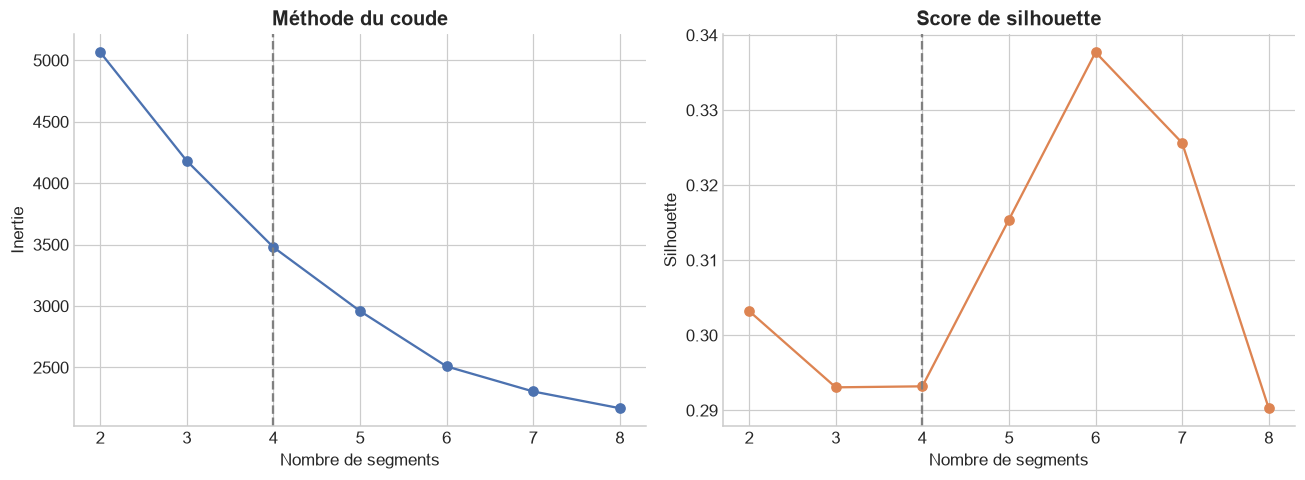

,k,Inertie,Silhouette
0,2,5065.0,0.303
1,3,4181.0,0.293
2,4,3479.0,0.293
3,5,2959.0,0.315
4,6,2508.0,0.338
5,7,2304.0,0.326
6,8,2168.0,0.290


In [5]:
ks = range(2, 9)
inerties, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=GRAINE).fit(X)
    inerties.append(km.inertia_)
    silhouettes.append(silhouette_score(X, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(ks, inerties, marker="o", color=BLEU)
axes[0].set_title("Méthode du coude"); axes[0].set_xlabel("Nombre de segments"); axes[0].set_ylabel("Inertie")
axes[1].plot(ks, silhouettes, marker="o", color=ORANGE)
axes[1].set_title("Score de silhouette"); axes[1].set_xlabel("Nombre de segments"); axes[1].set_ylabel("Silhouette")
for ax in axes:
    ax.axvline(4, color="grey", ls="--", lw=1.5)
fig.tight_layout(); sauver(fig, "m3_01_choix_k"); plt.show()

pd.DataFrame({"k": list(ks), "Inertie": np.round(inerties), "Silhouette": np.round(silhouettes, 3)})

**Commentaire.** La courbe d'inertie s'infléchit nettement entre 3 et 5 segments, puis les gains deviennent faibles. Le score de silhouette est assez plat : il vaut environ 0,29 pour 4 segments et atteint 0,34 pour 6 segments.

Nous retenons malgré tout **4 segments**. Le passage à 6 segments n'apporte pas de nouveaux comportements : il découpe un même groupe de petits acheteurs en trois sous-groupes de 46 à 75 clients qui se distinguent seulement par la catégorie achetée. Avec 4 segments, les groupes sont de taille comparable (168 à 198 clients), chacun correspond à un comportement clairement identifiable, et ils sont exploitables pour une stratégie marketing. Un score de silhouette modéré est normal ici : la clientèle forme un continuum plutôt que des groupes parfaitement séparés.

Ce choix illustre un principe important de la segmentation : le nombre de groupes ne se décide pas uniquement sur un critère statistique, mais aussi sur l'utilité des groupes obtenus.

## 3. Segmentation par K-means

In [6]:
K = 4
kmeans = KMeans(n_clusters=K, n_init=20, random_state=GRAINE).fit(X)
acheteurs["Segment_ID"] = kmeans.labels_

print(f"Score de silhouette : {silhouette_score(X, kmeans.labels_):.3f}")
acheteurs["Segment_ID"].value_counts().sort_index().rename("Nombre de clients").to_frame()

Score de silhouette : 0.293


,Nombre de clients
Segment_ID,
0,168
1,184
2,198
3,176


## 4. Vérification par classification hiérarchique

Pour vérifier que les groupes ne dépendent pas de la méthode choisie, nous appliquons une classification ascendante hiérarchique (méthode de Ward) sur les mêmes données, et nous comparons les deux découpages avec l'indice de Rand ajusté (ARI). Un ARI de 1 signifie des découpages identiques, un ARI de 0 un accord dû au hasard.

Indice de Rand ajusté entre K-means et classification hiérarchique : 0.739


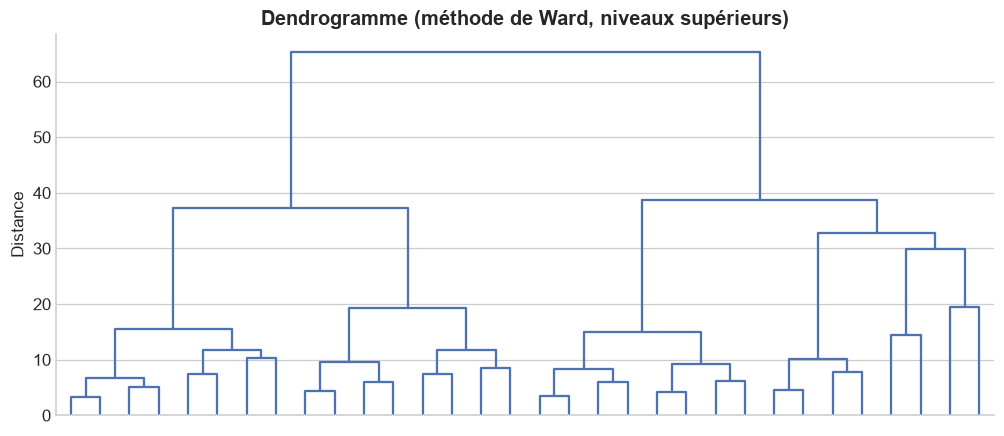

Hiérarchique,0,1,2,3
K-means,,,,
0,161,0,4,3
1,0,172,0,12
2,48,0,147,3
3,7,3,0,166


In [7]:
cah = AgglomerativeClustering(n_clusters=K, linkage="ward").fit_predict(X)
ari = adjusted_rand_score(kmeans.labels_, cah)
print(f"Indice de Rand ajusté entre K-means et classification hiérarchique : {ari:.3f}")

fig, ax = plt.subplots(figsize=(11, 4.5))
dendrogram(linkage(X, method="ward"), truncate_mode="level", p=4, no_labels=True,
           color_threshold=0, above_threshold_color=BLEU, ax=ax)
ax.set_title("Dendrogramme (méthode de Ward, niveaux supérieurs)")
ax.set_ylabel("Distance")
sauver(fig, "m3_02_dendrogramme"); plt.show()

pd.crosstab(acheteurs["Segment_ID"], cah, rownames=["K-means"], colnames=["Hiérarchique"])

**Commentaire.** L'indice de Rand ajusté vaut environ 0,74, ce qui traduit un accord fort entre les deux méthodes. Le tableau croisé montre que les groupes se correspondent largement, avec quelques clients classés différemment aux frontières. La structure trouvée n'est donc pas un artefact du K-means : elle existe bien dans les données. Le dendrogramme confirme une séparation en quelques grandes branches.

## 5. Visualisation des segments

Les clients sont décrits par 10 variables, ce qui est impossible à représenter directement. Nous utilisons deux méthodes de réduction de dimension :

- **PCA** : projection linéaire qui conserve un maximum de variance et permet d'interpréter les axes.
- **t-SNE** : projection non linéaire qui cherche à préserver le voisinage local ; elle sépare souvent mieux visuellement, mais les distances entre groupes n'y sont pas interprétables.

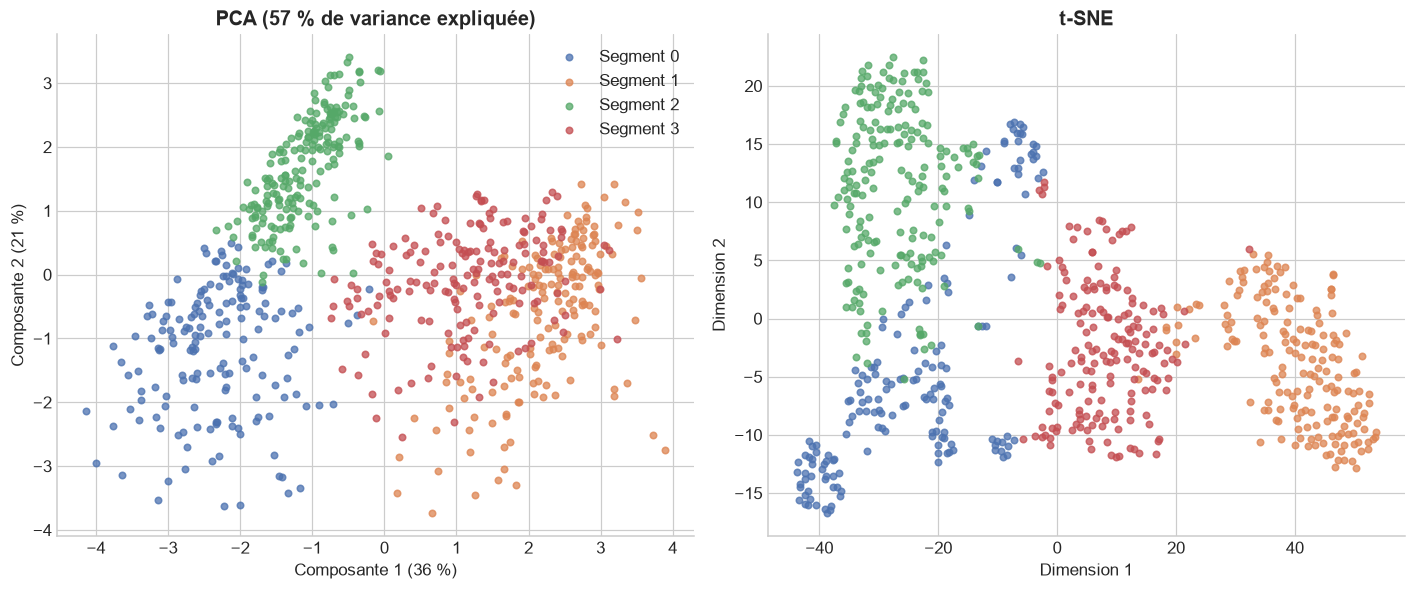

In [8]:
pca = PCA(n_components=2, random_state=GRAINE)
coord_pca = pca.fit_transform(X)
variance = pca.explained_variance_ratio_

tsne = TSNE(n_components=2, random_state=GRAINE, perplexity=30, init="pca")
coord_tsne = tsne.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for seg in range(K):
    masque = acheteurs["Segment_ID"] == seg
    axes[0].scatter(coord_pca[masque, 0], coord_pca[masque, 1], s=18, alpha=0.75,
                    color=COULEURS_SEG[seg], label=f"Segment {seg}")
    axes[1].scatter(coord_tsne[masque, 0], coord_tsne[masque, 1], s=18, alpha=0.75,
                    color=COULEURS_SEG[seg], label=f"Segment {seg}")
axes[0].set_title(f"PCA ({variance.sum() * 100:.0f} % de variance expliquée)")
axes[0].set_xlabel(f"Composante 1 ({variance[0] * 100:.0f} %)")
axes[0].set_ylabel(f"Composante 2 ({variance[1] * 100:.0f} %)")
axes[1].set_title("t-SNE"); axes[1].set_xlabel("Dimension 1"); axes[1].set_ylabel("Dimension 2")
axes[0].legend()
fig.tight_layout(); sauver(fig, "m3_03_pca_tsne"); plt.show()

In [9]:
contributions = pd.DataFrame(pca.components_.T, index=VARIABLES, columns=["Composante 1", "Composante 2"])
contributions.round(2).sort_values("Composante 1")

,Composante 1,Composante 2
Part_Accessories,-0.34,0.03
Part_Online,-0.27,0.29
Recence_Jours,-0.25,-0.40
Part_Clothing,-0.24,0.25
Part_Footwear,-0.10,-0.04
log_Nb_Achats,0.19,0.61
Age,0.28,-0.29
log_Montant_Total,0.40,0.42
Panier_Moyen,0.45,-0.15
Part_Outerwear,0.46,-0.19


**Commentaire.** Les deux projections montrent des groupes bien distincts, en particulier avec t-SNE. Le tableau des contributions permet d'interpréter les axes de la PCA : la première composante oppose principalement les clients orientés Outerwear, avec des paniers élevés, aux clients orientés Clothing et Accessories, avec des paniers plus faibles ; la seconde oppose les clients jeunes et actifs en ligne aux clients plus âgés et fidèles au magasin. Les deux premières composantes ne résument qu'une partie de l'information, ce qui est normal avec 10 variables : les graphiques servent à visualiser, pas à décider.

# M4 – Profilage des segments

## 6. Profil moyen de chaque segment

In [10]:
COLONNES_PROFIL = ["Age", "Nb_Achats", "Montant_Total", "Panier_Moyen", "Recence_Jours",
                   "Part_Online", "Part_Clothing", "Part_Footwear", "Part_Outerwear",
                   "Part_Accessories", "Anciennete_Jours"]

profils = acheteurs.groupby("Segment_ID")[COLONNES_PROFIL].mean().round(1)
profils.insert(0, "Nb_Clients", acheteurs["Segment_ID"].value_counts().sort_index())
profils["Part_CA"] = (acheteurs.groupby("Segment_ID")["Montant_Total"].sum()
                      / acheteurs["Montant_Total"].sum() * 100).round(1)
profils

,Nb_Clients,Age,Nb_Achats,Montant_Total,Panier_Moyen,Recence_Jours,Part_Online,Part_Clothing,Part_Footwear,Part_Outerwear,Part_Accessories,Anciennete_Jours,Part_CA
Segment_ID,,,,,,,,,,,,,
0,168,32.1,2.2,101.3,47.2,358.0,64.4,40.3,17.6,1.0,41.2,809.5,3.5
1,184,39.1,6.2,1049.2,170.1,136.0,44.9,2.6,2.8,94.2,0.4,831.4,39.8
2,198,22.9,11.8,678.1,57.8,104.9,84.0,50.5,20.0,1.5,27.9,850.2,27.7
3,176,52.2,8.4,797.3,93.0,79.2,14.8,39.8,18.1,37.6,4.5,870.0,29.0


In [11]:
# Produits les plus achetés et canal dominant par segment
ventes_seg = ventes.merge(acheteurs[["Customer_ID", "Segment_ID"]], on="Customer_ID")
top_produits = (ventes_seg.groupby("Segment_ID")["Product_Name"]
                .apply(lambda s: ", ".join(s.value_counts().head(3).index)))
canal = acheteurs.groupby("Segment_ID")["Canal_Prefere"].apply(
    lambda s: f"{s.value_counts(normalize=True).idxmax()} ({s.value_counts(normalize=True).max() * 100:.0f} %)")
pd.DataFrame({"Top 3 produits": top_produits, "Canal dominant": canal})

,Top 3 produits,Canal dominant
Segment_ID,,
0,"Scarf, Hat, T-shirt",Online (70 %)
1,"Coat, Parka, Blazer",In-Store (56 %)
2,"T-shirt, Shorts, Shirt",Online (99 %)
3,"Jeans, Dress, Hoodie",In-Store (100 %)


### 6.1 Comparaison visuelle des segments

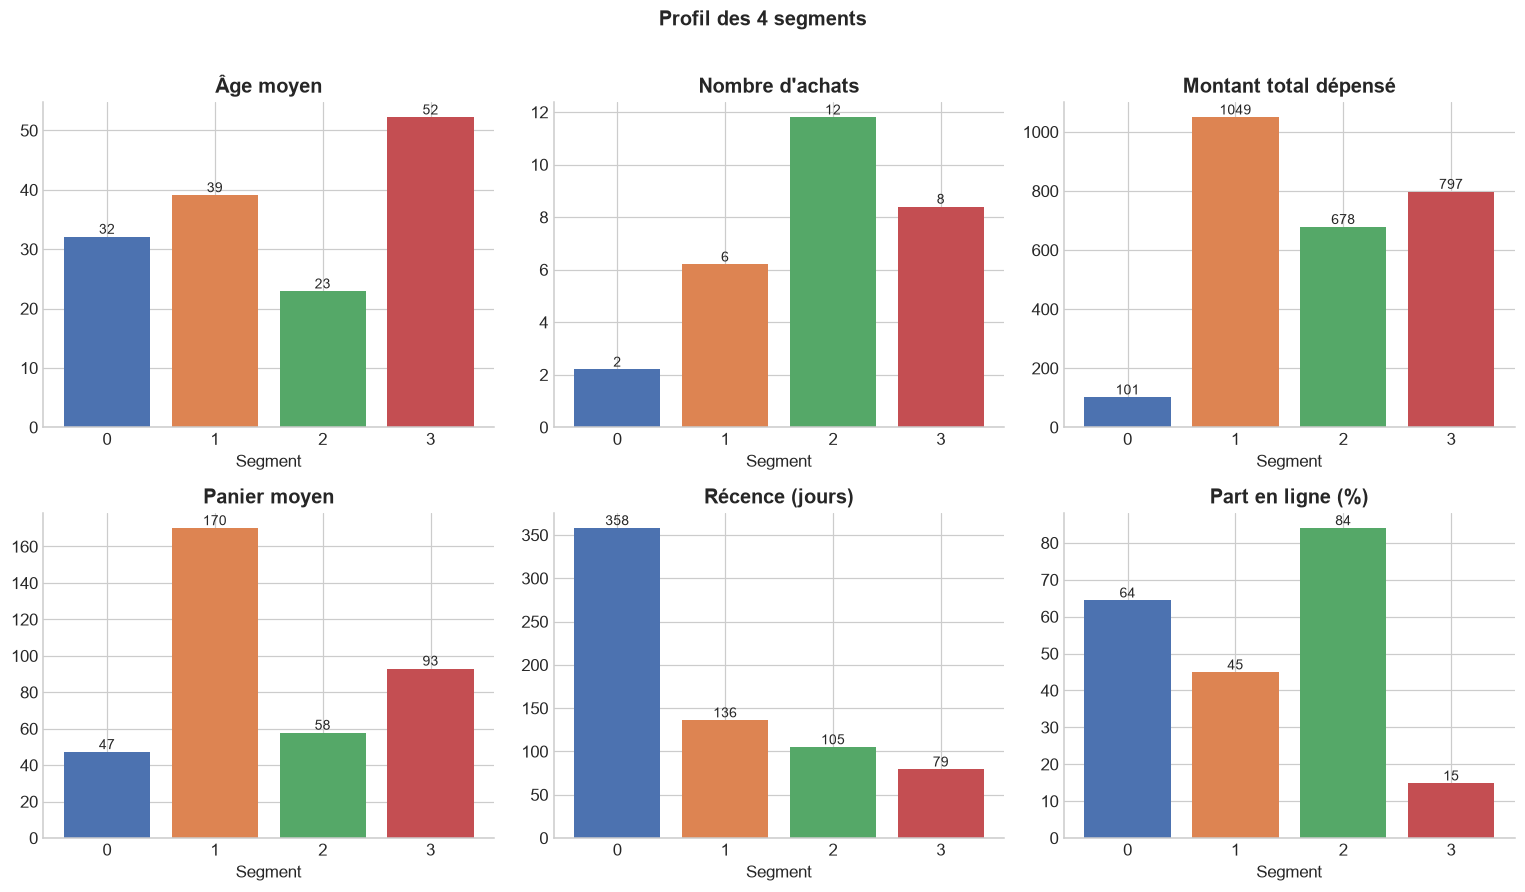

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
mesures = [("Age", "Âge moyen"), ("Nb_Achats", "Nombre d'achats"), ("Montant_Total", "Montant total dépensé"),
           ("Panier_Moyen", "Panier moyen"), ("Recence_Jours", "Récence (jours)"), ("Part_Online", "Part en ligne (%)")]
for ax, (col, titre) in zip(axes.ravel(), mesures):
    ax.bar(profils.index.astype(str), profils[col], color=COULEURS_SEG)
    ax.set_title(titre); ax.set_xlabel("Segment")
    ax.bar_label(ax.containers[0], fmt="%.0f", fontsize=9)
fig.suptitle("Profil des 4 segments", fontweight="bold", y=1.01)
fig.tight_layout(); sauver(fig, "m4_01_profils_segments"); plt.show()

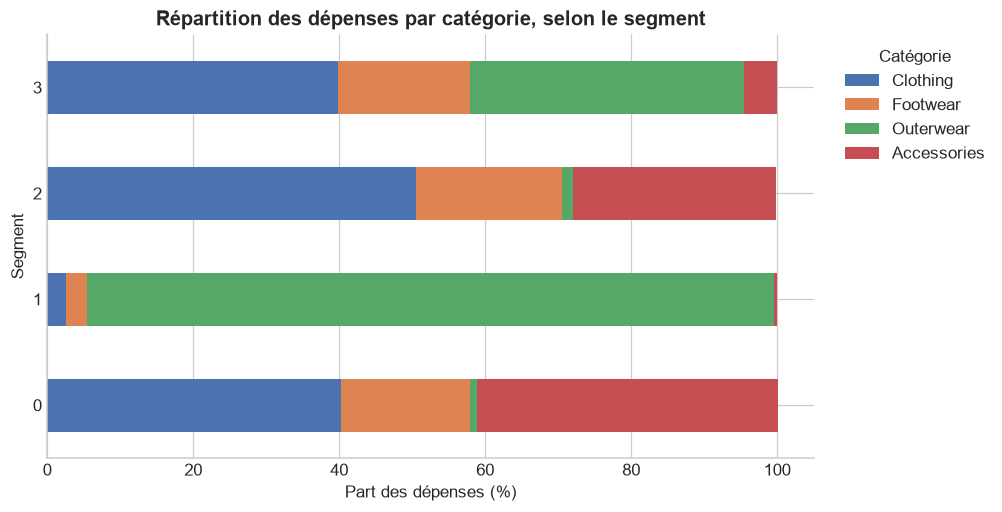

In [13]:
parts = profils[["Part_Clothing", "Part_Footwear", "Part_Outerwear", "Part_Accessories"]]
parts.columns = ["Clothing", "Footwear", "Outerwear", "Accessories"]
fig, ax = plt.subplots(figsize=(9, 5))
parts.plot.barh(stacked=True, ax=ax, color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
ax.set_title("Répartition des dépenses par catégorie, selon le segment")
ax.set_xlabel("Part des dépenses (%)"); ax.set_ylabel("Segment")
ax.legend(title="Catégorie", bbox_to_anchor=(1.02, 1), loc="upper left")
sauver(fig, "m4_02_categories_segments"); plt.show()

**Commentaire.** Les quatre segments se distinguent nettement sur toutes les dimensions.

- Le **segment 0** regroupe des clients d'environ 32 ans qui achètent très peu (2 achats en moyenne), pour de petits montants, et qui n'ont plus acheté depuis près d'un an. Leurs dépenses vont surtout aux accessoires.
- Le **segment 1** réunit des clients d'environ 39 ans dont les dépenses vont presque exclusivement à l'Outerwear (94 %). Avec un panier moyen de 170, ils réalisent près de 40 % du chiffre d'affaires alors qu'ils ne représentent qu'un quart des clients.
- Le **segment 2** rassemble les plus jeunes (23 ans), qui achètent très souvent (près de 12 achats) et presque uniquement en ligne, mais avec des paniers faibles.
- Le **segment 3** correspond aux clients les plus âgés (52 ans), fidèles au magasin, avec des achats réguliers, récents et un panier intermédiaire.

### 6.2 Croisement avec les prédictions de churn (M6)

,Proba_Churn,CLV
Segment_ID,,
0,0.87,125.60
1,0.44,1262.73
2,0.41,790.72
3,0.26,960.05


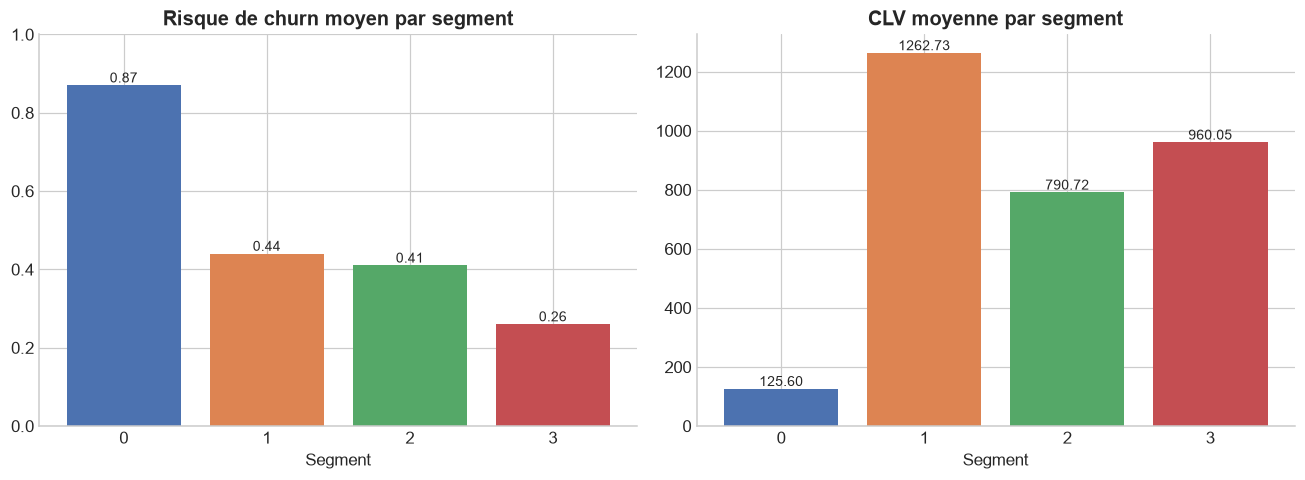

In [14]:
fichier_churn = RESULTS / "predictions_churn.csv"
if fichier_churn.exists():
    churn = pd.read_csv(fichier_churn)
    croisement = (acheteurs.merge(churn, on="Customer_ID")
                  .groupby("Segment_ID")[["Proba_Churn", "CLV"]].mean().round(2))
    display(croisement)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].bar(croisement.index.astype(str), croisement["Proba_Churn"], color=COULEURS_SEG)
    axes[0].set_title("Risque de churn moyen par segment"); axes[0].set_ylim(0, 1)
    axes[1].bar(croisement.index.astype(str), croisement["CLV"], color=COULEURS_SEG)
    axes[1].set_title("CLV moyenne par segment")
    for ax in axes:
        ax.set_xlabel("Segment"); ax.bar_label(ax.containers[0], fmt="%.2f", fontsize=9)
    fig.tight_layout(); sauver(fig, "m4_03_churn_clv_segments"); plt.show()
else:
    print("predictions_churn.csv non trouvé : croisement à refaire une fois M6 livré.")

**Commentaire.** Le croisement avec les résultats de M6 confirme la lecture des segments et oriente directement la stratégie :

- le segment 0 a un risque de churn très élevé (0,87) et la CLV la plus faible : ce sont des clients largement perdus, dont la réactivation coûterait plus qu'elle ne rapporterait ;
- le segment 1 a la CLV la plus élevée (plus de 1 200) mais un risque de churn non négligeable (0,44) : c'est le segment prioritaire pour la fidélisation, puisque chaque départ y coûte cher ;
- le segment 3 est le plus fidèle (churn 0,26) avec une CLV élevée : c'est la base stable de l'entreprise ;
- le segment 2 se situe entre les deux, avec un churn modéré et une CLV moyenne.

## 7. Nommage des segments et personas

Les noms ci-dessous sont tirés directement des caractéristiques observées dans les tableaux précédents.

In [15]:
NOMS_SEGMENTS = {
    0: "Acheteurs ponctuels inactifs",
    1: "Clients premium Outerwear",
    2: "Jeunes acheteurs en ligne",
    3: "Fidèles en magasin",
}
acheteurs["Segment_Nom"] = acheteurs["Segment_ID"].map(NOMS_SEGMENTS)
profils_nommes = profils.copy()
profils_nommes.index = [f"{i} – {NOMS_SEGMENTS[i]}" for i in profils_nommes.index]
profils_nommes

,Nb_Clients,Age,Nb_Achats,Montant_Total,Panier_Moyen,Recence_Jours,Part_Online,Part_Clothing,Part_Footwear,Part_Outerwear,Part_Accessories,Anciennete_Jours,Part_CA
0 – Acheteurs ponctuels inactifs,168,32.1,2.2,101.3,47.2,358.0,64.4,40.3,17.6,1.0,41.2,809.5,3.5
1 – Clients premium Outerwear,184,39.1,6.2,1049.2,170.1,136.0,44.9,2.6,2.8,94.2,0.4,831.4,39.8
2 – Jeunes acheteurs en ligne,198,22.9,11.8,678.1,57.8,104.9,84.0,50.5,20.0,1.5,27.9,850.2,27.7
3 – Fidèles en magasin,176,52.2,8.4,797.3,93.0,79.2,14.8,39.8,18.1,37.6,4.5,870.0,29.0


### Persona 1 — Segment 0 : « Acheteurs ponctuels inactifs »

**Sandra, 32 ans, employée, Chicago**

- **Poids** : 168 clients (23 %), mais seulement 3,5 % du chiffre d'affaires
- **Comportement** : 2 achats en moyenne, 101 dépensés au total, panier moyen de 47
- **Canal** : en ligne dans 70 % des cas
- **Produits** : accessoires (41 % de ses dépenses) et vêtements simples — écharpes, chapeaux, t-shirts
- **Statut** : dernier achat il y a environ un an, risque de churn de 0,87, CLV de 126

**Ce qu'elle cherche :** un achat ponctuel, souvent un cadeau ou une petite envie, à prix bas. Elle n'a pas d'attachement à la marque.

**Ses freins :** elle ne voit pas de raison de revenir ; elle ne se souvient probablement plus de la marque.

**Enjeu marketing :** segment à faible valeur. Une campagne de réactivation à faible coût (email automatisé) peut être testée, mais il ne faut pas y investir un budget important.

---

### Persona 2 — Segment 1 : « Clients premium Outerwear »

**Marc, 39 ans, cadre, Los Angeles**

- **Poids** : 184 clients (25 %) mais **39,8 % du chiffre d'affaires** — le segment le plus rentable
- **Comportement** : 6 achats, 1 049 dépensés, panier moyen de 170 (le plus élevé)
- **Canal** : équilibré, avec une légère préférence pour le magasin (56 %)
- **Produits** : Outerwear à 94 % de ses dépenses — manteaux, parkas, blazers
- **Statut** : dernier achat il y a environ 4 mois, risque de churn de 0,44, **CLV de 1 263 (la plus élevée)**

**Ce qu'il cherche :** des pièces de qualité, durables, avec une vraie valeur perçue. Il achète peu souvent mais cher, et se déplace volontiers en magasin pour essayer.

**Ses freins :** il n'achète que par saison, principalement à l'approche de l'hiver ; hors saison, il n'a aucune raison de revenir.

**Enjeu marketing :** segment prioritaire. Son risque de churn de 0,44 est préoccupant au vu de sa valeur : chaque départ coûte très cher. À traiter par un programme de fidélité, des avant-premières sur les nouvelles collections et un contact personnalisé avant la saison d'hiver.

---

### Persona 3 — Segment 2 : « Jeunes acheteurs en ligne »

**Léa, 23 ans, étudiante, San Diego**

- **Poids** : 198 clients (27 %), 27,7 % du chiffre d'affaires
- **Comportement** : près de 12 achats (le plus fréquent), 678 dépensés, panier moyen de 58 seulement
- **Canal** : **84 % en ligne** — quasiment jamais en magasin
- **Produits** : vêtements courants (50 %) et accessoires (28 %) — t-shirts, shorts, chemises
- **Statut** : dernier achat il y a environ 3 mois, risque de churn de 0,41, CLV de 791

**Ce qu'elle cherche :** de la nouveauté, des prix accessibles, une expérience d'achat rapide sur mobile. Elle achète souvent, par petites quantités.

**Ses freins :** budget limité, très sensible au prix et aux frais de livraison ; volatile face à la concurrence.

**Enjeu marketing :** segment à faire monter en valeur. Le levier principal est l'augmentation du panier moyen (offres groupées, seuil de livraison gratuite) plutôt que la fréquence, déjà élevée. Canaux à privilégier : réseaux sociaux et email.

---

### Persona 4 — Segment 3 : « Fidèles en magasin »

**Patricia, 52 ans, cadre, Houston**

- **Poids** : 176 clients (24 %), 29 % du chiffre d'affaires
- **Comportement** : 8 achats, 797 dépensés, panier moyen de 93
- **Canal** : **magasin à 100 %** — la part en ligne n'est que de 15 %
- **Produits** : répartition équilibrée entre vêtements (40 %) et Outerwear (38 %) — jeans, robes, sweats
- **Statut** : dernier achat il y a moins de 3 mois (le plus récent), **risque de churn de 0,26 (le plus faible)**, CLV de 960

**Ce qu'elle cherche :** du conseil, l'essayage, une relation de confiance avec le magasin. Elle achète régulièrement, sur toute l'année.

**Ses freins :** peu réceptive aux canaux numériques ; une communication uniquement en ligne la ferait passer à côté.

**Enjeu marketing :** base stable de l'entreprise, à préserver. Actions en magasin, carte de fidélité, invitations à des événements privés. Une transition douce vers le canal en ligne peut être testée, sans forcer.

## 8. Livrable : `data/results/segments.csv`

Les clients sans achat sont conservés avec le segment `-1`, pour que le dashboard dispose de la totalité des clients.

In [16]:
segments = acheteurs[["Customer_ID", "Segment_ID", "Segment_Nom"]].copy()
inactifs_out = pd.DataFrame({"Customer_ID": inactifs["Customer_ID"],
                             "Segment_ID": -1, "Segment_Nom": "Clients sans achat"})
segments = pd.concat([segments, inactifs_out]).sort_values("Customer_ID").reset_index(drop=True)
segments.to_csv(RESULTS / "segments.csv", index=False)

print(f"{len(segments)} lignes écrites dans data/results/segments.csv")
segments["Segment_Nom"].value_counts().rename("Nombre de clients").to_frame()

805 lignes écrites dans data/results/segments.csv


,Nombre de clients
Segment_Nom,
Jeunes acheteurs en ligne,198
Clients premium Outerwear,184
Fidèles en magasin,176
Acheteurs ponctuels inactifs,168
Clients sans achat,79


## 9. Synthèse

| Segment | Nom | Clients | Part du CA | Panier moyen | Churn | CLV | Priorité |
|---|---|---|---|---|---|---|---|
| 1 | Clients premium Outerwear | 184 | 39,8 % | 170 | 0,44 | 1 263 | **Fidélisation prioritaire** |
| 3 | Fidèles en magasin | 176 | 29,0 % | 93 | 0,26 | 960 | Préserver |
| 2 | Jeunes acheteurs en ligne | 198 | 27,7 % | 58 | 0,41 | 791 | Monter en valeur |
| 0 | Acheteurs ponctuels inactifs | 168 | 3,5 % | 47 | 0,87 | 126 | Réactivation à faible coût |

**Ce qu'il faut retenir pour la stratégie (M7) :**

1. Le chiffre d'affaires repose sur deux segments, Premium Outerwear et Fidèles en magasin, qui font ensemble 69 % du total avec moins de la moitié des clients.
2. Le canal doit être choisi selon le segment : le magasin pour les segments 1 et 3, le numérique pour le segment 2.
3. Le segment 1 cumule la plus forte valeur et un risque de départ élevé : c'est là que l'effort de fidélisation rapportera le plus.
4. Le segment 2 achète déjà souvent : le levier est le montant du panier, pas la fréquence.
5. Le segment 0 ne justifie pas d'investissement lourd, seulement une réactivation automatisée à faible coût.

**Limite à rappeler dans le rapport.** Les données analysées sont générées (voir `docs/regles_donnees.md`). Les segments obtenus sont donc valables sous les hypothèses de génération, et la méthode compte davantage que les valeurs chiffrées elles-mêmes.